In [20]:
import pandas as pd
# import utils as uti
from utils import results as res
import matplotlib.pyplot as plt
import pickle

In [2]:
df_train = pd.read_pickle("../data/train_df.pkl")
df_test = pd.read_pickle("../data/test_df.pkl")
walds = pd.read_pickle("../data/walds.pkl")

In [3]:
with open("../data/models.pkl", "rb") as file:
    models = pickle.load(file)

In [4]:
walds.head()

,var,wald,corr,corr ind
0,V14,1455.634827,-0.098727,False
1,V4,1297.380483,-0.106859,False
2,V10,1183.148737,-0.100605,False
3,V2,1163.591804,-0.535577,True
4,V3,1134.292483,-0.417851,True


In [5]:
models

{'logi': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x7ed987f14980>,
 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8447411578889518, device=None,
               early_stopping_rounds=None, enable_categorical=True,
               eval_metric='auc', feature_types=None, feature_weights=None,
               gamma=1.3949386065204183, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.034646653174710614,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=3.6473162849112093, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, ...),
 'rf': RandomForestClassifier(class_weight='balanced_subsample', 

# predict logistic

In [6]:
import statsmodels.api as sm

In [7]:
models['logi'].params.index.tolist()[1:]

['V14', 'V4', 'V12', 'V13']

In [8]:
tmp = sm.add_constant(
    df_train[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_train['logi'] = models['logi'].predict(tmp)

In [9]:
tmp = sm.add_constant(
    df_test[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_test['logi'] = models['logi'].predict(tmp)

# predict XGB

In [10]:
df_train['xgb'] = models['xgb'].predict_proba(df_train[models['xgb'].get_booster().feature_names])[:, 1]

In [11]:
df_test['xgb'] = models['xgb'].predict_proba(df_test[models['xgb'].get_booster().feature_names])[:, 1]

# predict Random Forest

In [12]:
df_train['rf'] = models['rf'].predict_proba(df_train[models['rf'].feature_names_in_.tolist()])[:, 1]

In [13]:
df_test['rf'] = models['rf'].predict_proba(df_test[models['rf'].feature_names_in_.tolist()])[:, 1]

# perfect prediction

In [14]:
df_train.sort_values(by='Class', inplace= True)
df_train['perf'] = range(len(df_train))

In [15]:
df_test.sort_values(by='Class', inplace=True)
df_test['perf'] = range(len(df_test))

# compare performance

In [16]:
df_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,logi,xgb,rf,perf
109011,71174.0,-2.108259,1.173406,1.614294,0.482867,0.067209,-0.191013,0.191246,-1.705859,-0.177615,...,0.400474,-0.413089,-0.348291,0.215298,19.99,0.0,0.000349,0.000446,0.0,0
133535,80429.0,-0.855705,-0.148187,2.545324,-0.936748,-0.521145,-0.067124,0.495980,0.044905,0.828457,...,-0.340606,0.722398,-0.155674,-0.116298,88.85,0.0,0.000344,0.000084,0.0,1
105849,69717.0,-1.106737,0.668748,1.341003,0.933475,0.376444,-0.128874,0.271983,0.221286,-0.439344,...,0.013865,-0.193264,0.107301,0.234618,24.98,0.0,0.000569,0.000267,0.0,2
230195,146231.0,1.745974,-0.603811,-0.449013,1.240330,-0.619052,-0.056696,-0.547876,0.157395,0.877337,...,-0.162028,-0.567007,0.024601,-0.029081,105.00,0.0,0.000490,0.000166,0.0,3
193065,129979.0,1.824455,-1.130767,-0.624745,-1.482597,-0.870230,-0.340117,-0.650900,-0.073264,2.230565,...,-0.316091,-0.370049,0.030102,-0.004634,132.10,0.0,0.000048,0.000089,0.0,4


In [17]:
df_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,logi,xgb,rf,perf
62125,50139.0,1.157527,-1.667179,0.873225,-0.842167,-1.950670,-0.035952,-1.183210,0.016793,-1.105799,...,0.381963,-0.095658,0.061311,0.043135,137.45,0.0,0.000275,0.000151,0.0,0
131964,79804.0,1.197725,0.346987,0.441015,0.905296,-0.094776,-0.354856,0.075393,-0.061984,-0.340156,...,0.413573,-0.631093,0.025484,0.019357,9.99,0.0,0.000102,0.000140,0.0,1
165036,117156.0,1.934841,-1.121273,-0.352190,-0.079542,-1.331119,-0.575178,-0.838136,-0.138740,0.328853,...,-0.169082,-0.178855,0.050933,-0.018910,90.67,0.0,0.000196,0.000093,0.0,2
271756,164725.0,2.102373,-0.279266,-1.644408,0.286656,0.394249,-0.195728,0.002842,-0.153651,0.922407,...,0.308647,0.736255,-0.077935,-0.071718,12.31,0.0,0.000308,0.000086,0.0,3
194748,130741.0,-0.913360,-0.141398,-0.425748,-3.290592,1.759517,3.655667,-0.931296,1.530835,-0.963198,...,0.109211,-0.144618,0.252182,0.100254,29.00,0.0,0.000079,0.000101,0.0,4


In [18]:
models_names = {
    "Logistic regression": "logi",
    "XGBoost WoE": "xgb",
    "Random Forest": "rf",
    "Perfect": "perf"    
}

## ROC

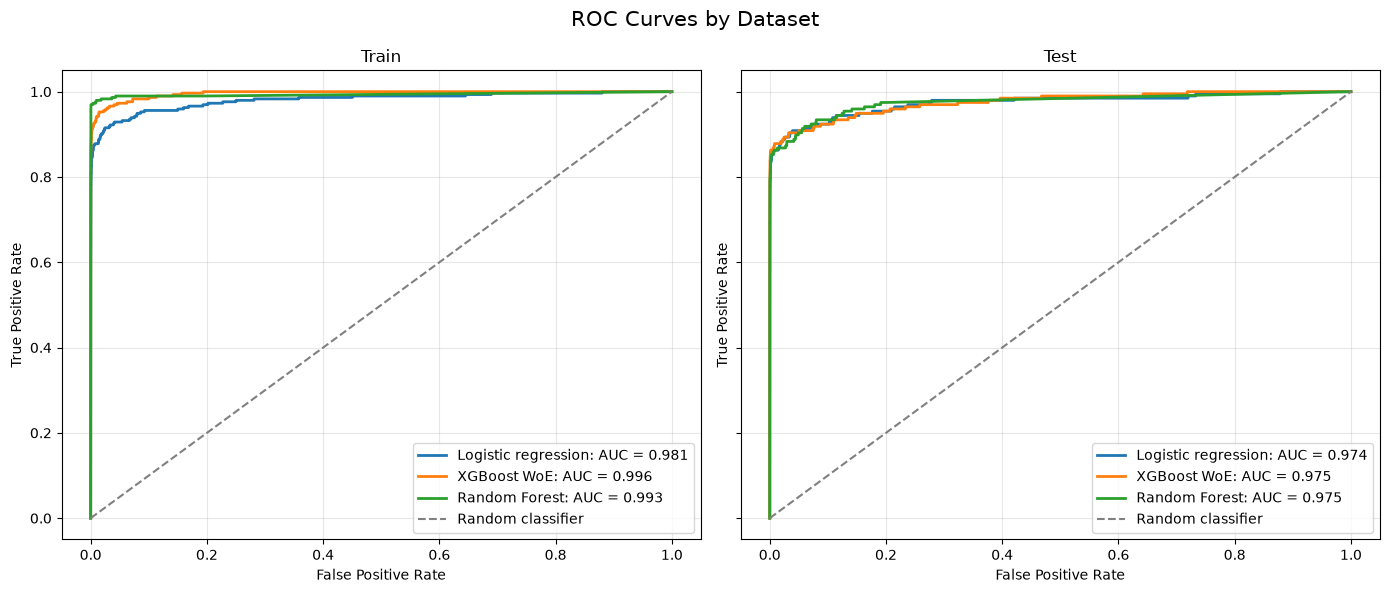

In [21]:
res.roc_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="Class"
)

## Lift

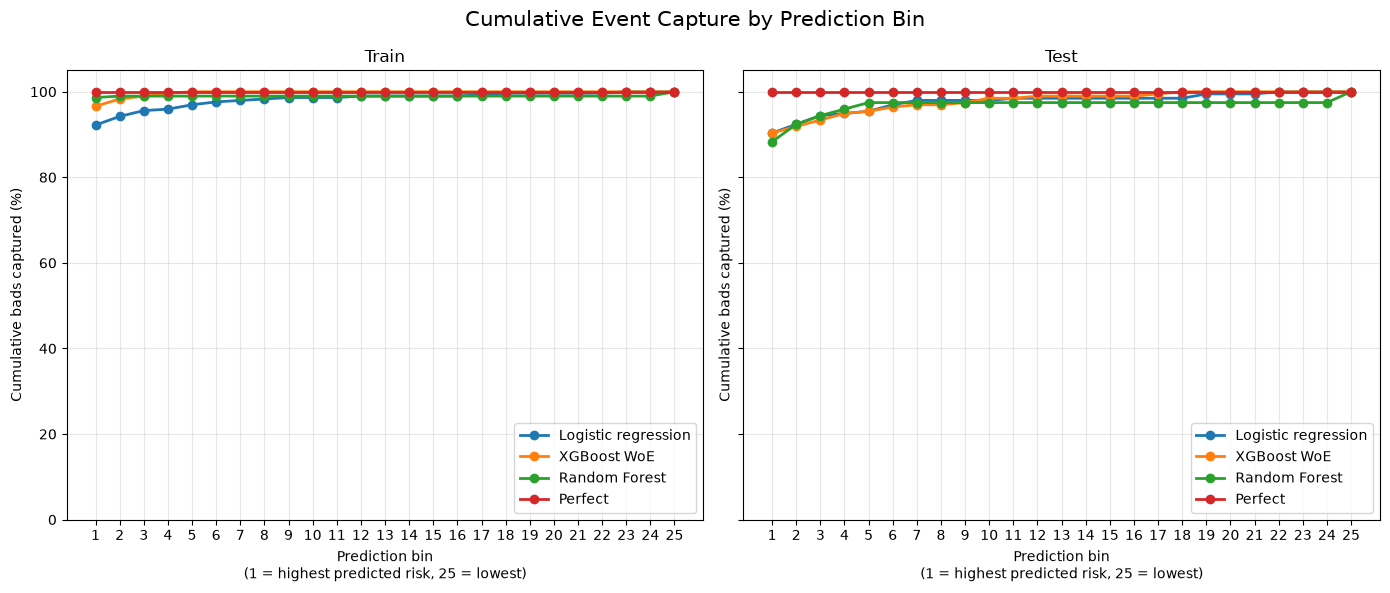

In [22]:
res.cumulative_event_rate_plot(
    df_1=df_train,
    df_2=df_test,
    models=models_names,
    target_name="Class",
    n_bins=25
)

## KS

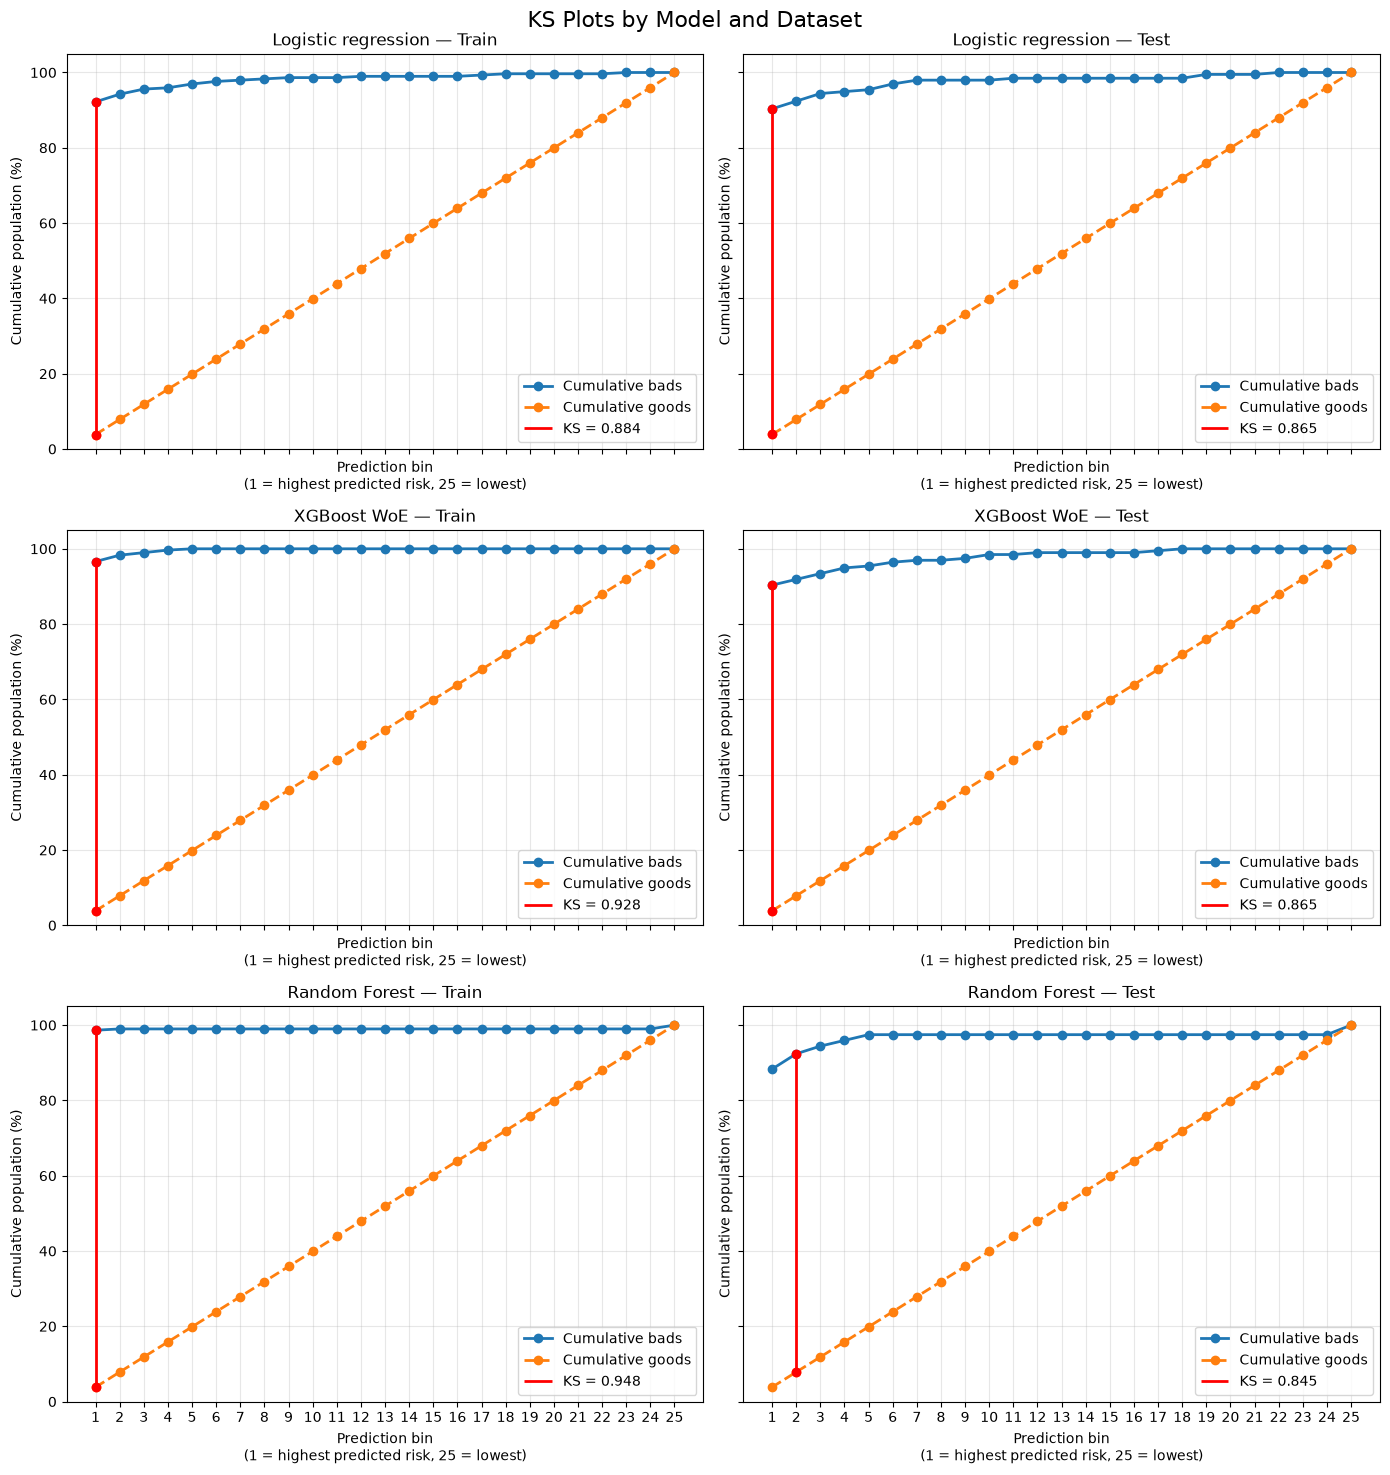

In [23]:
res.ks_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="Class",
    n_bins=25
)

# calibration

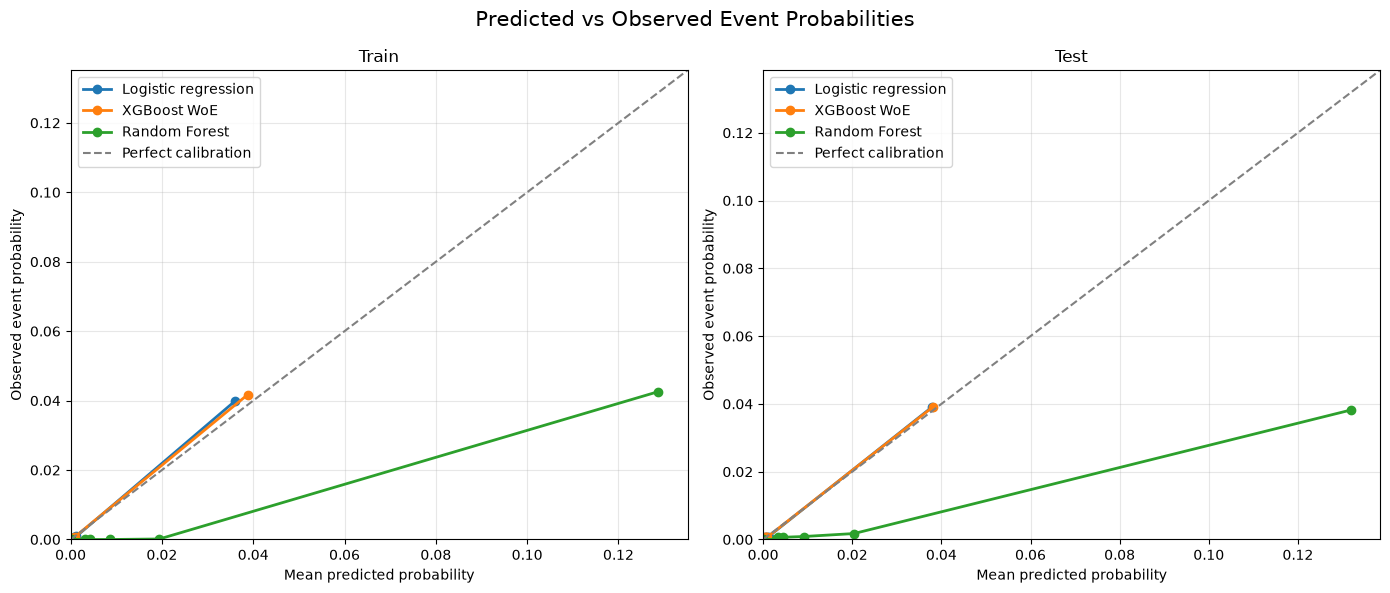

In [24]:
res.calibration_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="Class",
    n_bins=25
)

# save predictions

In [25]:
df_train['sample'] = 'train'
df_test['sample'] = 'test'

In [26]:
results = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

In [27]:
results.to_pickle("../data/results_df.pkl")